<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

In [ ]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from bioMONAI.core import *
from bioMONAI.core import Path
from bioMONAI.data import get_image_files, get_target, RandomSplitter
from bioMONAI.nets import BasicUNet, DynUNet
from bioMONAI.losses import *
from bioMONAI.losses import SSIMLoss
from bioMONAI.metrics import *
from bioMONAI.datasets import download_file

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
device = get_device()
print(device)

cuda


### Download Data

In [ ]:
# Specify the directory where you want to save the downloaded files
output_directory = "../_data/U2OS"
# Define the base URL for the dataset
url = 'http://csbdeep.bioimagecomputing.com/example_data/snr_7_binning_2.zip'

# Download only the first two images
# download_file(url, output_directory, extract=True)

### Create Dataloader

In [ ]:
X_path = '../_data/U2OS/128a57f165e1044e34d9a6ef46e66b3c-snr_7_binning_2.zip.unzip/train/low/'
y_path = '../_data/U2OS/128a57f165e1044e34d9a6ef46e66b3c-snr_7_binning_2.zip.unzip/train/GT'

bs = 16
patch_size = 128

itemTfms = [ScaleIntensityPercentiles(), RandCropND(patch_size), RandRot90(prob=.75), RandFlip(prob=0.5)]
batchTfms = []

get_target_fn = get_target(y_path, same_filename=True)

data = BioDataLoaders.from_folder(
    X_path, 
    get_target_fn, 
    valid_pct=0.05, 
    seed=42, 
    item_tfms=itemTfms,
    batch_tfms=batchTfms, 
    show_summary=True,
    bs = bs,
    )

# print length of training and validation datasets
print('train images:', len(data.train_ds.items), '\nvalidation images:', len(data.valid_ds.items))

Setting-up type transforms pipelines
Found 2457 items
2 datasets of sizes 2335,122
Setting up Pipeline: BioImage.create -> Tensor2BioImage -- {}
Setting up Pipeline: get_target.<locals>.generate_target_path -> BioImage.create -> Tensor2BioImage -- {}

Building one sample
  Pipeline: BioImage.create -> Tensor2BioImage -- {}
    starting from
      ../_data/U2OS/128a57f165e1044e34d9a6ef46e66b3c-snr_7_binning_2.zip.unzip/train/low/img_1596.tif
    applying BioImage.create gives
      BioImage of size 1x256x256
    applying Tensor2BioImage -- {} gives
      BioImage of size 1x256x256
  Pipeline: get_target.<locals>.generate_target_path -> BioImage.create -> Tensor2BioImage -- {}
    starting from
      ../_data/U2OS/128a57f165e1044e34d9a6ef46e66b3c-snr_7_binning_2.zip.unzip/train/low/img_1596.tif
    applying get_target.<locals>.generate_target_path gives
      ../_data/U2OS/128a57f165e1044e34d9a6ef46e66b3c-snr_7_binning_2.zip.unzip/train/GT/img_1596.tif
    applying BioImage.create gives


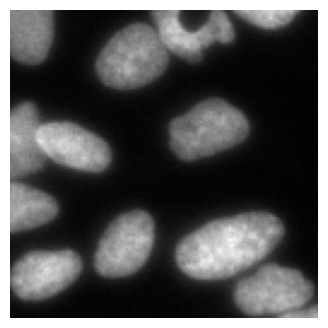

In [ ]:
data.show_batch(max_n=1)

### Load and train a 2D model

In [ ]:
# from bioMONAI.nets import Deeplab, DeeplabConfig
from monai.networks.nets import BasicUNet, AttentionUnet, DynUNet, UNet, BasicUNet

In [ ]:
# model = UNet(spatial_dims=2, in_channels=1, out_channels=1, channels=(16, 32, 64, 128, 256),strides=(2, 2, 2, 2), num_res_units=2).model
# model = AttentionUnet(spatial_dims=2, in_channels=1, out_channels=1, channels=(16, 32, 64),strides=(1, 1))
# model = DynUNet(spatial_dims=2, in_channels=1, out_channels=1, strides=(1, 2, 2),kernel_size=(3, 3, 3), upsample_kernel_size=(2, 2), res_block=True) # it tends to create hot pixels
# model = BasicUNet(spatial_dims=3, in_channels=1, out_channels=1)
# config_2d = DeeplabConfig(
#     dimensions=2,
#     in_channels=1,  
#     out_channels=1,
#     backbone="resnet10",  
# )
# model = Deeplab(config_2d)

In [ ]:
model = UNet(spatial_dims=2, in_channels=1, out_channels=1, channels=(32, 64, 128, 256),strides=(1, 2, 2), num_res_units=2)
# model = DynUNet(spatial_dims=2, in_channels=1, out_channels=1, strides=(1, 2, 2),kernel_size=(3, 3, 3), upsample_kernel_size=(2, 2), res_block=True) 

loss = CombinedLoss(alpha=0.00001, beta=0.00001)

metrics = [MSEMetric(), SSIMMetric(2)]

trainer = fastTrainer(data, model, loss_fn=loss, metrics=metrics, show_summary=False)

epoch,train_loss,valid_loss,MSE,SSIM,time
0,0.477725,0.509568,1.349756,0.490439,00:04
1,0.330525,0.303147,1.510545,0.696866,00:04
2,0.268879,0.309445,1.575054,0.690568,00:04
3,0.227137,0.221887,1.502905,0.778127,00:04
4,0.228147,0.310885,1.578870,0.689128,00:05
5,0.202863,0.186027,1.508807,0.813988,00:05
6,0.200529,0.182069,1.502204,0.817945,00:05
7,0.191378,0.185810,1.434534,0.814204,00:05
8,0.186754,0.181515,1.456065,0.818498,00:04
9,0.178258,0.221215,1.506446,0.778799,00:04


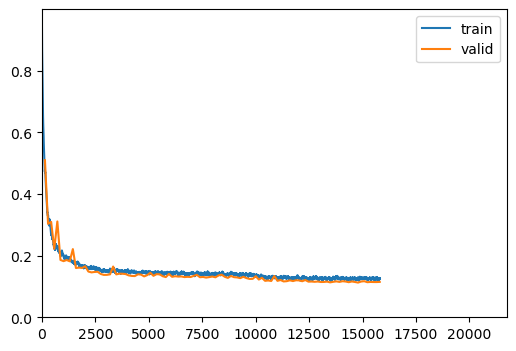

ERROR: Unexpected segmentation fault encountered in worker.
 

RuntimeError: Exception occured in `ProgressCallback` when calling event `after_batch`:
	DataLoader worker (pid 631689) is killed by signal: Segmentation fault. 

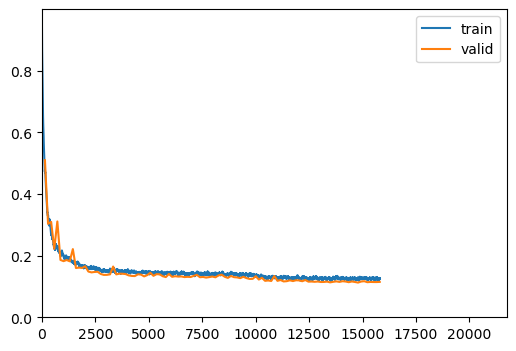

In [ ]:
trainer.fit_flat_cos(150)

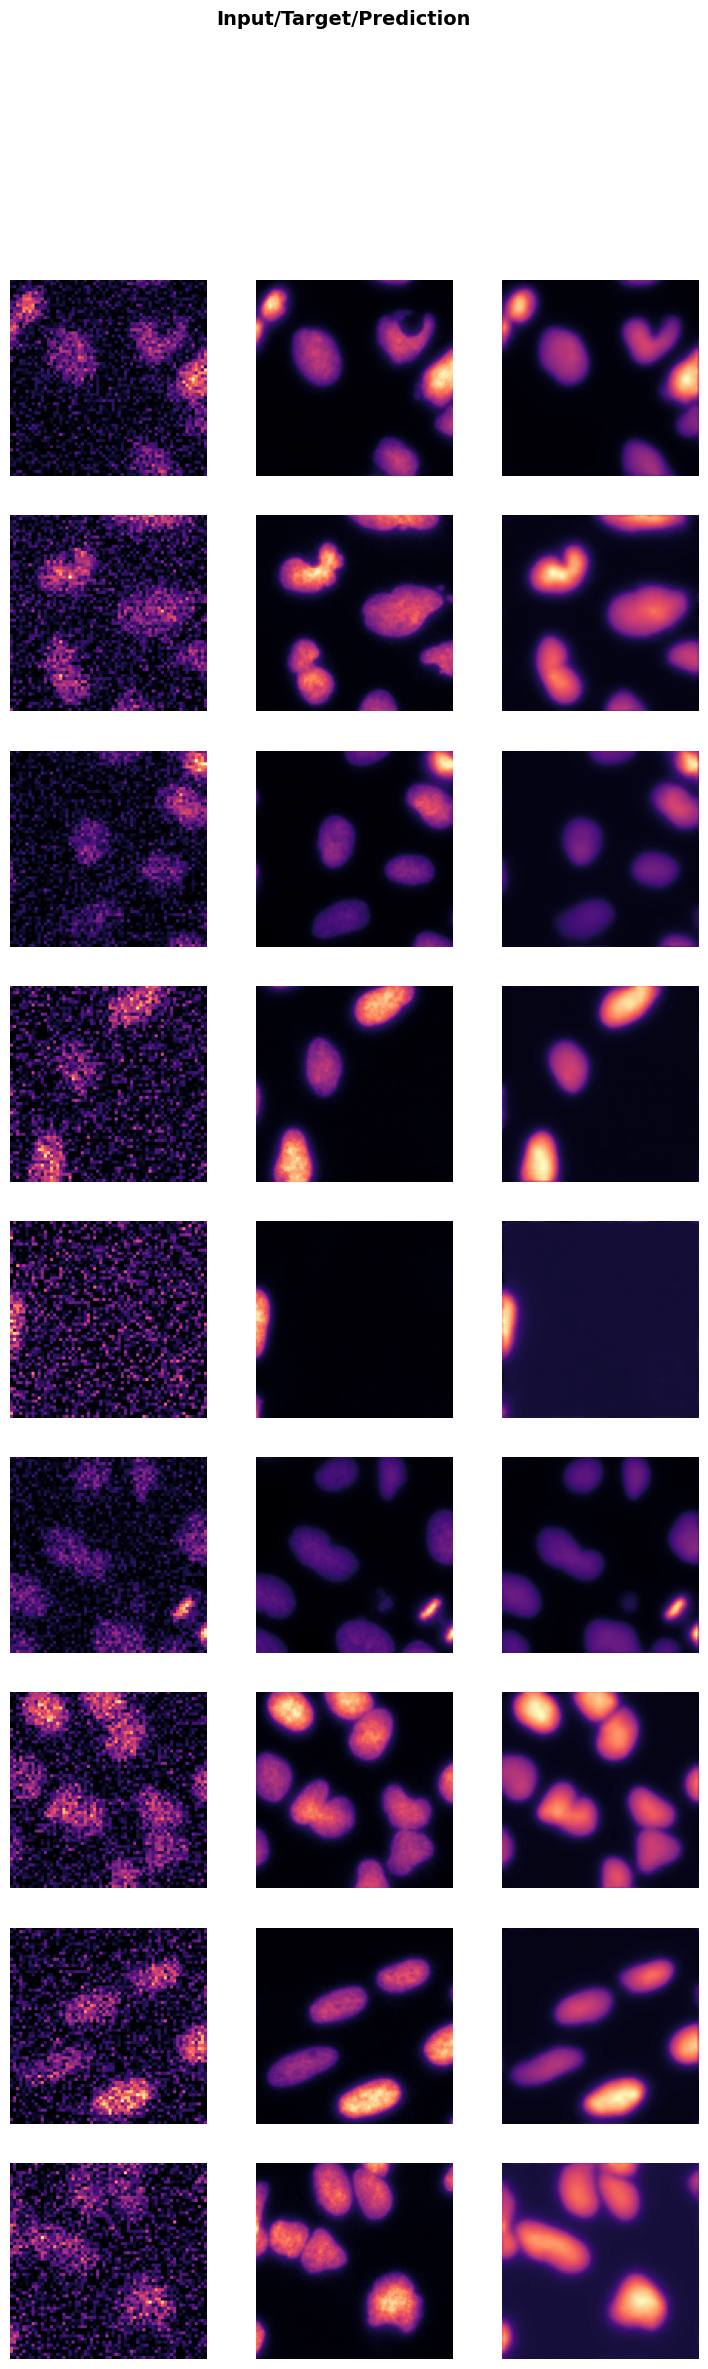

In [ ]:
trainer.show_results(cmap='magma')

In [ ]:
# trainer.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!